# Call Center Cleanup

For this assignment, we will be working with call center data. You can start working on the assignment after the first lesson on Exploratory Data Analysis with pandas. Make sure to read the whole assignment before starting anything! As you code along in the Jupyter notebook, you are asked to make note of the results of your analysis. Do so by clicking on the results box and adding your notes beside each question.

## Business Issue and Understanding

You are working for a company that has two call centers: the North Call Center and the South Call Center. The company is looking to possibly hire five additional reps to enhance customer experience. Your task is to explore how efficient the current reps are in each branch to determine which branch would benefit from additional assistance.

### How the Call Center Works

Call center representatives are assigned queues. When calls are assigned to a queue, the call is assigned to the next person in line in the queue. After a call is assigned to a representative, the amount of time between assignment and the call starting is divided into busy minutes and not ready minutes. If the call is incoming and a customer is waiting on the phone for a rep, the time is split into three categories: busy minutes, not ready minutes, and incoming call wait time. Once the rep has the customer on the phone, there might be during call wait time, where the call is put on hold while the rep gets an answer for the customer.

### Notes about the Dataset

If you haven't worked in a call center before, these notes might help you throughout your analysis.

* The call purpose is tagged for each call.
* The time of the call is tagged in 1 hour blocks starting at 9:00 AM and ending at 5:00 PM.
* Calls are tagged as incoming or outgoing.
* Reps are assigned to queues. When the reps are working, they take calls in the order of their queue.
* A call that is dropped due to technical error or missed by the center because they have reached maximum capacity is a lost call.
* An abandoned call is when the customer hangs up because they have been waiting for too long.
* Busy Minutes: the amount of time after a call comes in or needs to go out where the assigned rep is not available because they are busy with other customers.
* Not Ready Minutes: the amount of time after a call comes in or needs to go out where the assigned rep is not available because they are not ready (for example, getting water).
* Incoming Wait Time - amount of time after assigned rep is available to take the call customer waits for representative to pick up a call. This is tracked in seconds.
* During Call Wait Time - amount of time during call that customer has to wait for representative

## Getting Started

You have two CSVs at your disposal, `NorthCallCenter.csv` and `SouthCallCenter.csv`. Import the appropriate libraries and create two dataframes, one called `north_df` and one called `south_df`.

In [1]:
# Import the appropriate libraries with aliases
import pandas as pd
import numpy as np
# Create two new dataframes
north_df = pd.read_csv("NorthCallCenter.csv")
south_df = pd.read_csv("SouthCallCenter.csv")
north_df.head()

,Unnamed: 0,Branch,Call Purpose,Time Block,Incoming or Outgoing,Queue,Rep ID,Sale,Lost Call,Abandoned,Busy Minutes,Not Ready Minutes,Incoming Wait Time,During Call Wait Time,Calls
0,0,North,Complaint,9:00 AM,Incoming,B,Brent,NO,0,1,9,2,1.0,4,1
1,1,North,Sales Support,11:00 AM,Incoming,A,Cam,NO,0,0,11,1,1.0,3,1
2,2,North,Sales Support,11:00 AM,Incoming,B,Todd,NO,0,0,9,3,1.0,3,1
3,3,North,Sales Support,4:00 PM,Incoming,B,Brent,NO,0,0,11,2,1.0,4,1
4,4,North,Product Support,12:00 PM,Incoming,B,Brent,NO,0,0,8,2,1.0,4,1


## Task 1: Exploratory Data Analysis

Time to do some EDA! In the process of learning more about the two datasets, answer the following questions. Use the code blocks below to begin cleaning your data. At the end of the section, record your answers.

#### EDA Question 1A:  How many reps are in the North branch?  

In [2]:
# EDA Question 1A solution below:
north_df["Rep ID"].nunique()
# 9

9

#### EDA Question 1B:  How many reps are in the South branch?  

In [3]:
# EDA Question 1B solution Below:
south_df["Rep ID"].nunique()
# 11

11

#### EDA Question 2A:  What is the average busy minutes, not ready minutes, incoming wait time, and during call wait time for the North branch? 

In [4]:
# EDA Question 2A solution Below:
print(north_df["Busy Minutes"].mean(), north_df["Not Ready Minutes"].mean(), 
      north_df["Incoming Wait Time"].mean(), north_df["During Call Wait Time"].mean())
# 9.99, 1.91, 3.05, 2.96

9.987755102040817 1.9142857142857144 3.048780487804878 2.9673469387755103


#### EDA Question 2B:  What is the average busy minutes, not ready minutes, incoming wait time, and during call wait time for the South branch? 

In [5]:
# EDA Question 2B solution Below:
print(south_df["Busy Minutes"].mean(), south_df["Not Ready Minutes"].mean(), 
      south_df["Incoming Wait Time"].mean(), south_df["During Call Wait Time"].mean())
# 10.05, 1.91, 3.00, 3.08

10.054140127388536 1.910828025477707 3.0 3.0764331210191083


#### EDA Question 3:  What is the number of calls taken for each time block(Both North and South combined)?

In [6]:
# EDA Question 3 solution Below:

# concatenated dfs and checking:
df = pd.concat([north_df, south_df], ignore_index=True)
df.shape
# now we can use one value_counts expression:
df["Time Block"].value_counts()

Time Block
12:00 PM    120
10:00 AM     99
3:00 PM      73
2:00 PM      65
11:00 AM     56
4:00 PM      53
5:00 PM      43
1:00 PM      40
9:00 AM      10
Name: count, dtype: int64

##### Record your answers for the EDA section below:
- 1a) Reps in the North Branch = 9
- 1b) Reps in the South Branch = 11


- 2a) North Branch, (round to the nearest hundredth):
> - Busy Minutes = 9.99
> - Not Ready Minutes = 1.91
> - Incoming Wait Time = 3.05
> - During Call Wait Time = 2.96
- 2b) South Branch, (round to the nearest hundredth):
> - Busy Minutes = 10.05
> - Not Ready Minutes = 1.91
> - Incoming Wait Time = 3.00
> - During Call Wait Time = 3.08
- 3) Total Calls taken for all branches per time block:
> - 9:00AM   = 10
> - 10:00AM  = 99
> - 11:00AM  = 56
> - 12:00PM  = 120
> - 1:00PM   = 40
> - 2:00PM   = 65
> - 3:00PM   = 73
> - 4:00PM   = 53
> - 5:00PM   = 43



## Task 2: Cleaning Your Data 
Now you need to clean up the datasets. When cleaning the datasets, you may find that there isn't dirty data to clean. That is okay! Some questions you need to answer about the data sets.
* Add additional code blocks as needed to show how you came to your conclusions. Add comments in your code blocks to help others understand your thinking. 

#### Cleaning Question 1:  Is there any missing data and if yes explain what you would do with the missing data and why?

In [7]:
# Question 1 solution below

#Checking for nulls:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))
# Only column with nulls is Incoming Wait Time.
df["Incoming Wait Time"].unique()
# These seem to be counted in whole seconds.  Nulls are likely calls with <1s of Incoming Wait time
# So, we will go ahead and fill with 0
df["Incoming Wait Time"] = df["Incoming Wait Time"].fillna(0)


Unnamed: 0 - 0%
Branch - 0%
Call Purpose - 0%
Time Block - 0%
Incoming or Outgoing - 0%
Queue - 0%
Rep ID - 0%
Sale - 0%
Lost Call - 0%
Abandoned - 0%
Busy Minutes - 0%
Not Ready Minutes - 0%
Incoming Wait Time - 63%
During Call Wait Time - 0%
Calls - 0%


In [8]:
# Verifying no more nulls:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))
# Verified

Unnamed: 0 - 0%
Branch - 0%
Call Purpose - 0%
Time Block - 0%
Incoming or Outgoing - 0%
Queue - 0%
Rep ID - 0%
Sale - 0%
Lost Call - 0%
Abandoned - 0%
Busy Minutes - 0%
Not Ready Minutes - 0%
Incoming Wait Time - 0%
During Call Wait Time - 0%
Calls - 0%


#### Record your answer below:

> Your Answer: 63% of values for "Incoming Wait Time" are null.  I checked and the values for this are counted in whole seconds, with the longest time of all 559 calls being 5 seconds.  These nulls likely represent calls which were answered with less than 1 second of Incoming Wait Time.  I replaced all these values with 0.

#### Cleaning Question 2:  In the North data set, there are two separate "YES" values for a sale. Why and how did you rectify the issue?

In [9]:
# Cleaning Question 2 solution below:
df["Sale"].unique()
# Looks like theres 1+ values with trailing space.
# Rectifying and validating:
df["Sale"] = df["Sale"].str.rstrip()
df["Sale"].unique()

array(['NO', 'YES'], dtype=object)

##### Record your answer by below:
> Your Answer: I rectified this issue to improve data accuracy.  This issue was rectified by replacing all occurrances of
"Yes " with "Yes"

#### Cleaning Question 3:  Are there duplicates in the two data sets? If there are, how did you handle them?

In [10]:
# Cleaning Question 3 solution below:
df.duplicated().sum()
# No duplicates

np.int64(0)

##### Record your answer below:
> Your Answer: There are no duplicate rows in the data.

#### Cleaning Question 4:  Is any of the data in the two data sets unnecessary? If yes, how did you handle it?

In [11]:
# Cleaning Question 4 solution below:
df["Calls"].unique()
# This column is unnecessary.  It records number of calls for each call, and all values are "1".
# Also going to drop "Unnamed: 0" as this is just the index value:
df = df.drop(columns=["Calls"])
df = df.drop(columns=["Unnamed: 0"])

##### Record your answer below:
> Your Answer: Yes, the "Calls" column is unnecessary.  It was dropped.

In [12]:
# Also found that "Lost Call" and "Abandond" are 0/1. 
# Checking all values are correct:
#print(df["Lost Call"].unique())
#print(df["Abandoned"].unique())
# Converting to bool:
df["Abandoned"] = df["Abandoned"].astype("bool")
df["Lost Call"] = df["Lost Call"].astype("bool")
print(df["Abandoned"].dtype)

bool


## Task 3: Data Manipulation
Before you begin answering any questions, combine the two datasets together to create a third dataframe called df. You can use this third dataframe to compare the two call centers to company-wide trends.
* Add additional code blocks as needed to show how you came to your conclusions. Add comments in your code blocks to help others understand your thinking. Record your answer below.

In [13]:
# Create dataframe for the entire company named df
# Already did this in a previous step, but, to have an answer here:
df = df


#### Manipulation Question 1:  Group by Rep ID and sum the resulting structure. Sort by calls to determine which rep in each branch has the highest number of calls.

In [14]:
# Manipulation Question solution below:
# this took me a bit to figure out but here's what I came up with:
top_north = (df[(df["Branch"] == "North")].groupby("Rep ID").size().idxmax())
top_south = (df[(df["Branch"] == "South")].groupby("Rep ID").size().idxmax())
print(top_north, top_south)
print(df.groupby("Rep ID").size().sort_values(ascending=False))

Brent Eric
Rep ID
Brent     37
Eric      35
Randy     33
Sandy     32
Helga     31
Lilly     30
George    29
Kate      29
Todd      29
Duke      29
Karl      28
Joe       26
Susan     26
Josh      26
Sharon    25
Cam       24
Xander    24
Amanda    23
Andy      23
Alice     20
dtype: int64


##### Record your answer below
Rep with the hightest number of calls and their total calls:
- North Branch = Brent, 37
- South Branch = Eric, 35

#### Manipulation Question 2:  The average call abandonment rate is a KPI when it comes to determining call center efficiency. As you may recall, abandoned calls are calls where the customer hangs up due to long call times. What is the average call abandonment rate for each branch and the whole company? Do any of these fall out of the optimal range of 2-5%?

In [15]:
# Manipulation Question 2 solution below:

call_abdn_pct = ((df[df["Abandoned"] == True].shape[0]) / (df.shape[0]))
print(call_abdn_pct)
north_abdn_pct = ((df[((df["Branch"] == "North") & (df["Abandoned"] == True))].shape[0]) / df[df["Branch"] == "North"].shape[0])
print(north_abdn_pct)
south_abdn_pct = ((df[((df["Branch"] == "South") & (df["Abandoned"] == True))].shape[0]) / df[df["Branch"] == "South"].shape[0])
print(south_abdn_pct)

0.01967799642218247
0.02857142857142857
0.012738853503184714


##### Record your answer below:
Average Call Abandonment Rates (round to the nearest hundredth):
- North Branch = 2.85%
- South Branch = 1.27%
- Company Wide = 1.96%
- Do any of these fall out of the optimal range of 2-5%? All are at or below optimal range of 2-5%.

#### Manipulation Question 3:  Service level is another KPI when it comes to measuring call center efficiency. Service level is the percentage of calls answered within a specific number of seconds. In the case of your employer, their ideal time frame is 2 seconds. What is the percentage of calls answered within 2 seconds for each branch and the entire company?

In [16]:
# Manipulation Question 3 solution below:
service_level = ((df[df["Incoming Wait Time"] <= 2].shape[0]) / (df.shape[0]))
print(service_level)
print(df.shape[0])
north_svc_lvl = ((df[((df["Branch"] == "North") & (df["Incoming Wait Time"] <= 2))].shape[0]) / df[df["Branch"] == "North"].shape[0])
print(north_svc_lvl)
print(df[df["Branch"] == "North"].shape[0])
south_svc_lvl = ((df[((df["Branch"] == "South") & (df["Incoming Wait Time"] <= 2))].shape[0]) / df[df["Branch"] == "South"].shape[0])
print(south_svc_lvl)
print(df[df["Branch"] == "South"].shape[0])


0.7728085867620751
559
0.8
245
0.7515923566878981
314


##### Record your answer below:
Percentage of calls answered within 2 seconds, include # of calls:
- North Branch = 80.00%, 245 calls
- South Branch = 75.16%, 314 calls
- Company Wide = 77.28%, 559 calls

#### Manipulation Question 4: For each branch and the entire company, what is the average speed of answer?

In [17]:
# Manipulation Question 4 solution below:
avg_incoming_wait = df["Incoming Wait Time"].mean()
print(avg_incoming_wait)
avg_incoming_wait_n = df[df["Branch"] == "North"]["Incoming Wait Time"].mean()
print(avg_incoming_wait_n)
avg_incoming_wait_s = df[df["Branch"] == "South"]["Incoming Wait Time"].mean()
print(avg_incoming_wait_s)

1.1234347048300537
1.0204081632653061
1.2038216560509554


##### Record your answer by below:
Average speed of answer (rounded to nearest hundredth):
- North Branch in seconds = 1.02
- South Branch in seconds = 1.2
- Company Wide in seconds = 1.12

## Task 4: Visualization

Create a visualization for each of the following questions. Some of the code to handle aggregating and storing data may be written for you. For each visualization, you choose the chart style that you feel suits the situation best. Make note of the chart style you chose and why. 

*NOTE Some questions you may decide to use more than one chart and or chart style.

#### Visualization 1:  What is the average abandonment rate per queue?

Text(0.5, 1.0, 'Call Abandonment Rate by Queue')

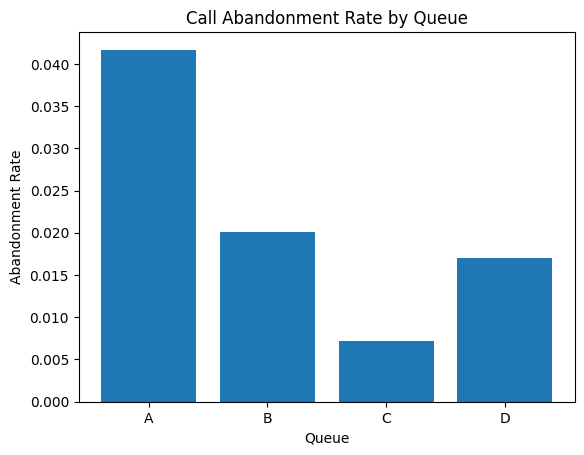

In [18]:
# Create visualization 1 here
# Import any additional libraries needed with alias
import matplotlib.pyplot as plt
# The dictionary abandonment_rates has the data you need.

# Editing this slightly as it uses a column I dropped.  Had to play around with this a bit as well.
abandonment_rates = {}
queues = ["A", "B", "C", "D"]
queue_dict = df.groupby("Queue")["Abandoned"].agg(["sum", "count"])
for q in queues:
    abandonment_rates[q] = (queue_dict.loc[q, "sum"]) / queue_dict.loc[q, "count"] 

#Your code below:
plt.bar(abandonment_rates.keys(), abandonment_rates.values())
plt.xlabel("Queue")
plt.ylabel("Abandonment Rate")
plt.title("Call Abandonment Rate by Queue")


##### Record your answer below:

> Chart style you chose and why: I chose a bar chart, as it is easy to read and suitable for comparing multiple values to one another.

#### Visualization 2: What is the service level percentage and average speed of answer for each rep in the North Branch?

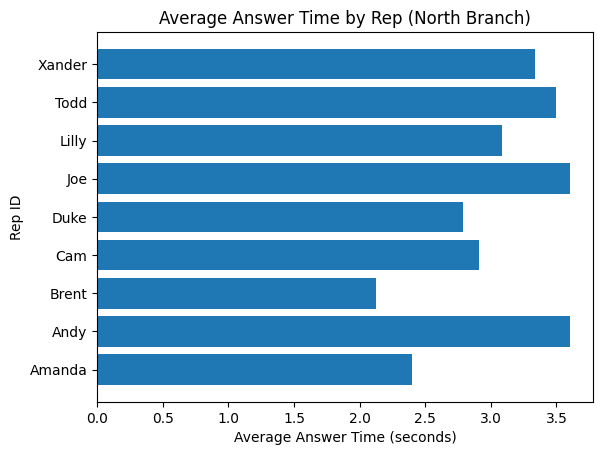

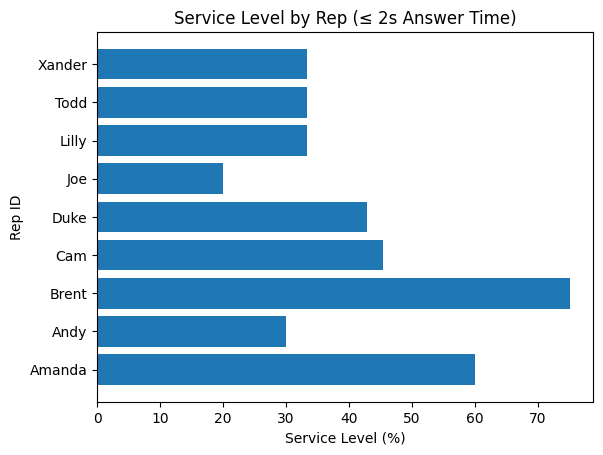

In [19]:
# Create visualization 2 here
# north_plt contains the data you need for the average speed of answer of each rep

north_plt = north_df.groupby("Rep ID")["Incoming Wait Time"].mean().to_frame().reset_index()

# Finding each Rep's Personal Service Level Percentage.  Basically, Calls within 2 secs / total calls

#Had to change these for same reason as last question.

# Table 1: Total Incoming calls less than 2 seconds grouped by Rep
quick_calls = north_df[north_df["Incoming Wait Time"] <= 2.0]
quick_reps = quick_calls[["Rep ID"]]
quick_stats = quick_reps.groupby(["Rep ID"]).size()  # Final Table


# Table 2: Total Incoming Calls Only grouped by Rep
total_calls_in = north_df[north_df["Incoming or Outgoing"] == "Incoming"]
rep_calls = total_calls_in[["Rep ID"]]     
total_stats = rep_calls.groupby(["Rep ID"]).size() # Final Table  

#  Table 3: Service Level Percentage created
# Changing this one as well due to above changes
service_level = (quick_stats / total_stats * 100)

#Your Code Here:
plt.barh(north_plt["Rep ID"], north_plt["Incoming Wait Time"])
plt.xlabel("Average Answer Time (seconds)")
plt.ylabel("Rep ID")
plt.title("Average Answer Time by Rep (North Branch)")
plt.show()

plt.barh(north_plt["Rep ID"], service_level)
plt.xlabel("Service Level (%)")
plt.ylabel("Rep ID")
plt.title("Service Level by Rep (≤ 2s Answer Time)")
plt.show()


##### Record your answer below:

> Chart style you chose and why: I chose a horizontal bar chart, as it is better for comparing a larger number of categories than a vertical bar chart.

#### Visualization 3: For each type of call purpose, how many calls are outgoing vs. incoming?

Call Purpose     Incoming or Outgoing
Complaint        Incoming                 51
Product Support  Outgoing                228
                 Incoming                 82
Sales Support    Outgoing                123
                 Incoming                 75
Name: count, dtype: int64


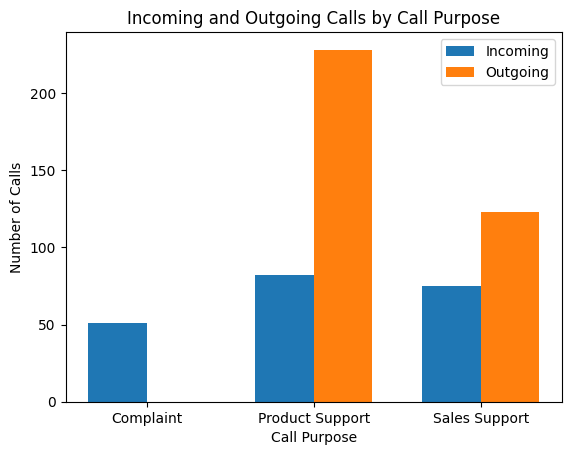

In [20]:
# Create visualization 3 here:
# The three dictionaries, complaints, sales_support, and product_support, have the information you need

purpose_group = df.groupby("Call Purpose")
call_purpose = ["Complaint", "Product Support", "Sales Support"]
purpose_counts = purpose_group["Incoming or Outgoing"].value_counts()
print(purpose_counts)

complaints = purpose_counts["Complaint"].to_dict()
sales_support = purpose_counts["Sales Support"].to_dict()
product_support = purpose_counts["Product Support"].to_dict()

#Your Code Here:

incoming_counts = [complaints.get("Incoming", 0), product_support.get("Incoming", 0), sales_support.get("Incoming", 0)]

outgoing_counts = [complaints.get("Outgoing", 0), product_support.get("Outgoing", 0),sales_support.get("Outgoing", 0)]

x = np.arange(len(call_purpose))
width = 0.35

plt.bar(x - width/2, incoming_counts, width, label="Incoming")
plt.bar(x + width/2, outgoing_counts, width, label="Outgoing")

plt.xticks(x, call_purpose)
plt.xlabel("Call Purpose")
plt.ylabel("Number of Calls")
plt.title("Incoming and Outgoing Calls by Call Purpose")
plt.legend()
plt.show()

##### Record your answer below:

> Chart style you chose and why:  I chose a grouped bar chart for easy readability of two call types per call reason.

## Task 5: Summarize Your Work

With what you know now about the two call centers and the entire company, answer the following questions. Note that while this is subjective, you should include relevant data to back up your opinion.


#### Summary Question 1:  Using KPIs such as average abandonment rate, service level and average speed of answer, in your opinion, which one of the two branches is operating more efficiently? Why?

##### Record your answer below:
> Your Answer: The North branch operates more efficiently.  It has a higher Service Level and faster Average Speed of Answer.  Though it has a higher Abandonment Rate, the rate still falls within the goal range of 2-5%.  Additionally, the North branch produces this performance with two fewer reps than the South branch.



#### Summary Question 2: Based on the number of reps in each branch and how quickly the reps are working, in your opinion, which branch would benefit from the extra help?

##### Record your answer below:
> Your Answer: Given that the metrics are comperable, though slightly favoring the North Branch, I think the South branch would benefit more from extra help.


#### Summary Question 3: Now that you have explored the datasets, is there any data or information that you wish you had in this analysis?

##### Record your answer below:
> Your Answer: Perhaps a more descriptive name for the queues, but this may not have been relevant to the business questions.


## Bonus Mission
Create a visualization that answers this question: For each call purpose, how many calls (incoming and outgoing) take place in each time block?
##### Record your answer below:

> Chart style you chose and why: 

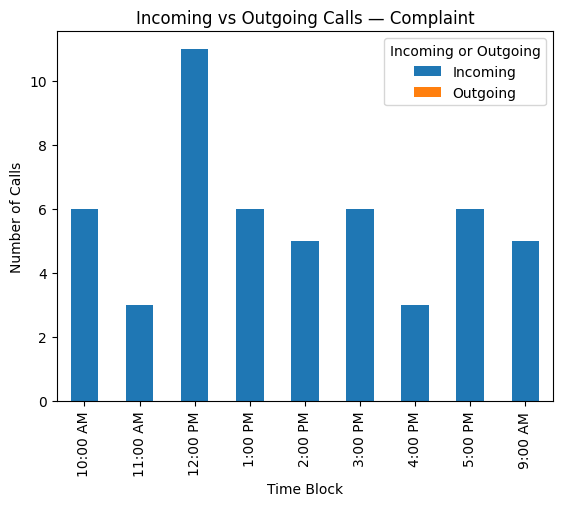

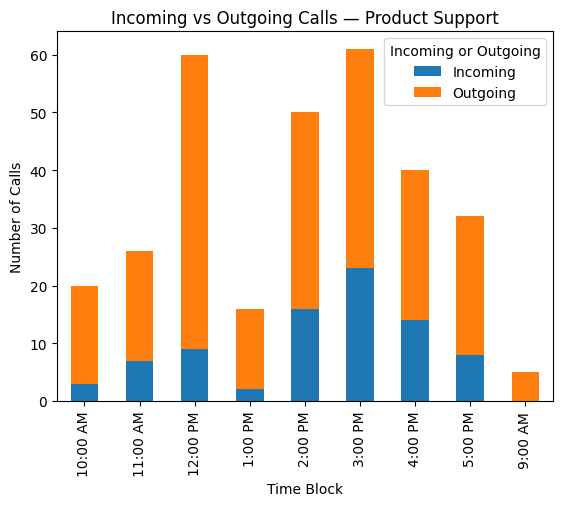

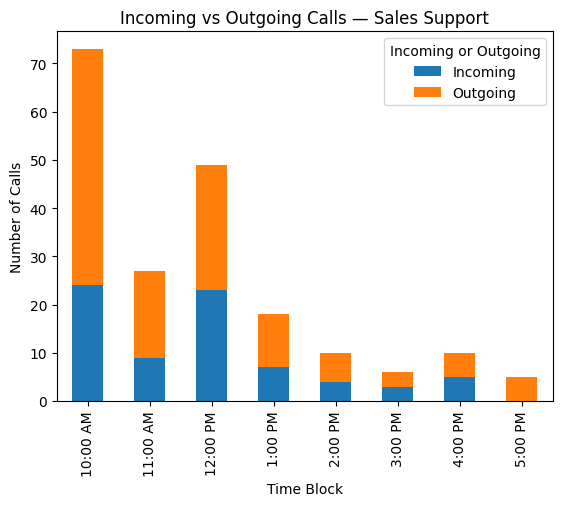

In [ ]:
# Create your Bonus Mission visualization here!
hourly = (df.groupby(["Call Purpose", "Time Block", "Incoming or Outgoing"]).size().unstack(fill_value=0))

for purpose in hourly.index.get_level_values(0).unique():
    hourly.loc[purpose].plot(kind="bar", stacked=True)
    plt.title(f"Incoming vs Outgoing Calls — {purpose}")
    plt.ylabel("Number of Calls")
    plt.xlabel("Time Block")
    plt.show()
